# E0 — Tuned-Lens Readout Validity

**Plan reference:** Phase 0, experiment E0 — calibration redo with a *real* tuned lens.

## Why this notebook exists

The first E0 notebook (`E0_readout_validity.ipynb`) compared the logit lens to a cheap
least-squares residual→residual translator. That fit used only ~263 tokens against
`d_model = 768`, so the ridge penalty dominated and every layer came out SUSPECT for setup
reasons as much as for lens reasons.

This notebook replaces the DIY "correct" meter with the published **Tuned Lens**
(Belrose et al.): per-layer affine translators trained to minimise KL to the model's final
next-token distribution. For GPT-2 small we **load a pretrained lens** rather than training
one from scratch.

**Still not a test of momentum.** Output is a depth range where fixed-direction / logit-lens
projections can be believed relative to the tuned lens.

## What this notebook does

1. Loads GPT-2 with `fold_ln=False` (required for the tuned-lens + TransformerLens bridge).
2. Loads the pretrained **TunedLens** and the package **LogitLens** for GPT-2.
3. On the forced-error prompt, compares W-vs-C logit differences (`25` − `27`) from both lenses
   layer by layer (primary calibration).
4. Re-fits the cheap ridge residual translator on **WikiText-2** (~tens of thousands of tokens)
   with a held-out R² check (secondary / diagnostic).
5. Keeps the E0b norm-growth plot and a norm-matched random-direction control.
6. Prints a trustworthy depth range under the **tuned-lens** comparison.

## How to read a result

- **Logit lens ≈ tuned lens from some layer onwards** → cheap logit lens is usable in that range.
- **They diverge in early/mid layers** → use the tuned lens (or discard) at those depths.
- **They diverge everywhere including late layers** → debug setup before concluding.
- **Ridge translator improves with WikiText but still disagrees with tuned lens** → more data
  helped the DIY fit, but the KL-trained lens remains the authoritative meter.

## Caveats

- Direction-specific plots still use **one prompt** unless you extend the prompt list.
- Re-run the primary comparison on 3–5 prompt variants before freezing a depth range for E2.
- First run downloads GPT-2 weights and the pretrained lens (needs network).
- J-lens / Jacobian correction is intentionally out of scope here.

In [2]:
# --- Install (uncomment on a fresh environment) ---------------------------------
# %pip install tuned-lens transformer-lens torch matplotlib numpy datasets

import torch
import numpy as np
import matplotlib.pyplot as plt
import transformer_lens as tl
from datasets import load_dataset
from tuned_lens.nn import TunedLens, Unembed, LogitLens

torch.set_grad_enabled(False)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cpu


## 1. Load model + pretrained lenses

`fold_ln=False` is required: the tuned lens applies the final LayerNorm itself, so LN must not
already be folded into the unembedding. This follows the official Tuned Lens + TransformerLens
tutorial.

Lens resource id `"gpt2"` loads the AlignmentResearch pretrained translators for GPT-2 small.

In [3]:
model = tl.HookedTransformer.from_pretrained(
    "gpt2",
    device=DEVICE,
    fold_ln=False,   # required for TunedLens bridge
)

N_LAYERS = model.cfg.n_layers   # 12
D_MODEL  = model.cfg.d_model    # 768
print(f"layers: {N_LAYERS}   d_model: {D_MODEL}")

tuned_lens = TunedLens.from_unembed_and_pretrained(
    unembed=Unembed(model),
    lens_resource_id="gpt2",
).to(DEVICE)

logit_lens = LogitLens.from_model(model).to(DEVICE)
print("loaded pretrained TunedLens + LogitLens for gpt2")

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2 into HookedTransformer
layers: 12   d_model: 768
loaded pretrained TunedLens + LogitLens for gpt2


## 2. Prompt, answer tokens, probe positions

Same forced-error prompt as the plan / original E0. We score
$\mathrm{logit}(25) - \mathrm{logit}(27)$ from each lens rather than a raw residual $\cdot\, w$
projection, so both meters speak in the same units (logit difference).

In [4]:
PROMPT = "12 + 15 = 25. Wait, let me recompute. 12 + 15 ="

tokens     = model.to_tokens(PROMPT)   # [1, seq]
str_tokens = model.to_str_tokens(PROMPT)
print("tokenisation:")
for i, t in enumerate(str_tokens):
    print(f"  {i:2d}  {t!r}")

W_STR, C_STR = " 25", " 27"
W_tok = model.to_single_token(W_STR)
C_tok = model.to_single_token(C_STR)
print(f"\nW = {W_STR!r} -> id {W_tok}      C = {C_STR!r} -> id {C_tok}")

# Still useful for the ridge arm and random-direction control (residual-space direction).
w_dir = model.W_U[:, W_tok] - model.W_U[:, C_tok]
print("w_dir shape:", tuple(w_dir.shape), " norm:", float(w_dir.norm()))


def find_token_indices(str_tokens, target):
    return [i for i, t in enumerate(str_tokens) if t == target]


impulse_positions = find_token_indices(str_tokens, " 25")
eq_positions      = find_token_indices(str_tokens, " =")
IMPULSE_POS = impulse_positions[0]
T_STAR      = eq_positions[-1]

print(f"impulse position (first ' 25'): {IMPULSE_POS}  -> {str_tokens[IMPULSE_POS]!r}")
print(f"probe position t* (final ' ='): {T_STAR}  -> {str_tokens[T_STAR]!r}")

tokenisation:
   0  '<|endoftext|>'
   1  '12'
   2  ' +'
   3  ' 15'
   4  ' ='
   5  ' 25'
   6  '.'
   7  ' Wait'
   8  ','
   9  ' let'
  10  ' me'
  11  ' recomp'
  12  'ute'
  13  '.'
  14  ' 12'
  15  ' +'
  16  ' 15'
  17  ' ='

W = ' 25' -> id 1679      C = ' 27' -> id 2681
w_dir shape: (768,)  norm: 1.7783163785934448
impulse position (first ' 25'): 5  -> ' 25'
probe position t* (final ' ='): 17  -> ' ='


## 3. Primary calibration — logit lens vs pretrained tuned lens

Following the official bridge, we read `resid_pre` at each layer index `0 … n_layers-1` and pass
it through `LogitLens` / `TunedLens` with that layer index. We also record the model's true final
logits as the last depth point.

Score at each (layer, position):

$$s = \mathrm{logit}(\text{“ 25”}) - \mathrm{logit}(\text{“ 27”})$$

In [5]:
logits_final, cache = model.run_with_cache(tokens, return_type="logits")
seq_len = tokens.shape[-1]

# Depth axis: one entry per layer (resid_pre @ lens), then the true final logits.
DEPTH_LABELS = [f"L{l}" for l in range(N_LAYERS)] + ["final"]
N_DEPTH = len(DEPTH_LABELS)
xs = np.arange(N_DEPTH)


def wc_diff_from_logits(layer_logits):
    """layer_logits: [batch, seq, d_vocab] -> [seq] W-vs-C logit difference."""
    return (layer_logits[0, :, W_tok] - layer_logits[0, :, C_tok]).detach().float().cpu().numpy()


score_logit = np.zeros((N_DEPTH, seq_len))
score_tuned = np.zeros((N_DEPTH, seq_len))

for layer in range(N_LAYERS):
    hidden = cache["resid_pre", layer]   # [1, seq, d_model]
    score_logit[layer] = wc_diff_from_logits(logit_lens.forward(hidden, layer))
    score_tuned[layer] = wc_diff_from_logits(tuned_lens.forward(hidden, layer))

score_logit[-1] = wc_diff_from_logits(logits_final)
score_tuned[-1] = wc_diff_from_logits(logits_final)   # identical at the true final output

print(f"W-vs-C logit diff at t*={T_STAR}, by depth:")
print(f"{'depth':>6}  {'logit lens':>12}  {'tuned lens':>12}")
for d, lab in enumerate(DEPTH_LABELS):
    print(f"{lab:>6}  {score_logit[d, T_STAR]:+12.3f}  {score_tuned[d, T_STAR]:+12.3f}")

W-vs-C logit diff at t*=17, by depth:
 depth    logit lens    tuned lens
    L0        +1.728        +1.091
    L1        +0.612        +0.643
    L2        +0.266        +0.364
    L3        +0.122        +0.210
    L4        -0.565        -0.205
    L5        +0.056        +0.110
    L6        +0.622        +0.462
    L7        +2.241        +1.364
    L8        +5.663        +3.217
    L9        +6.775        +3.489
   L10       +10.058        +4.772
   L11        +8.671        +4.726
 final        +4.194        +4.194


 depth     corr   sign agree
    L0   +0.930         1.00
    L1   +0.900         1.00
    L2   +0.837         1.00
    L3   +0.879         0.94
    L4   +0.933         0.83
    L5   +0.940         0.89
    L6   +0.951         0.94
    L7   +0.966         0.94
    L8   +0.981         0.94
    L9   +0.983         0.89
   L10   +0.994         0.89
   L11   +0.999         0.89
 final   +1.000         1.00


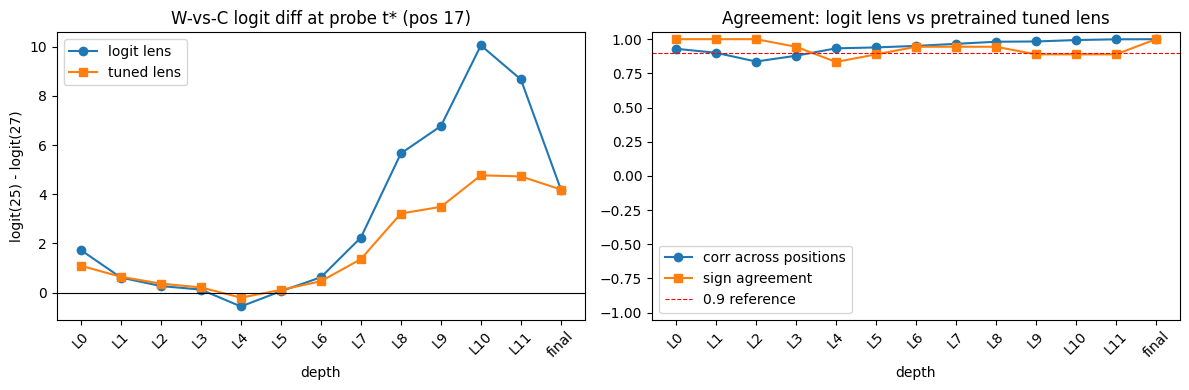

In [6]:
# Agreement across sequence positions (primary stats). Skip the final row for corr with itself.
corrs = np.array([
    np.corrcoef(score_logit[d], score_tuned[d])[0, 1] for d in range(N_LAYERS)
] + [1.0])
sign_agree = np.array([
    np.mean(np.sign(score_logit[d]) == np.sign(score_tuned[d])) for d in range(N_LAYERS)
] + [1.0])

print(f"{'depth':>6}  {'corr':>7}  {'sign agree':>11}")
for d, lab in enumerate(DEPTH_LABELS):
    print(f"{lab:>6}  {corrs[d]:+7.3f}  {sign_agree[d]:11.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(xs, score_logit[:, T_STAR], marker="o", label="logit lens")
axes[0].plot(xs, score_tuned[:, T_STAR], marker="s", label="tuned lens")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_xticks(xs)
axes[0].set_xticklabels(DEPTH_LABELS, rotation=45)
axes[0].set_title(f"W-vs-C logit diff at probe t* (pos {T_STAR})")
axes[0].set_xlabel("depth"); axes[0].set_ylabel("logit(25) - logit(27)"); axes[0].legend()

axes[1].plot(xs, corrs, marker="o", label="corr across positions")
axes[1].plot(xs, sign_agree, marker="s", label="sign agreement")
axes[1].axhline(0.9, color="red", ls="--", lw=0.8, label="0.9 reference")
axes[1].set_xticks(xs)
axes[1].set_xticklabels(DEPTH_LABELS, rotation=45)
axes[1].set_ylim(-1.05, 1.05)
axes[1].set_title("Agreement: logit lens vs pretrained tuned lens")
axes[1].set_xlabel("depth"); axes[1].legend()

plt.tight_layout(); plt.show()

In [7]:
def emergence_layer(series):
    """First index at which the series turns positive and stays positive through the end."""
    for i in range(len(series)):
        if np.all(series[i:] > 0):
            return i
    return None


e_logit = emergence_layer(score_logit[:, T_STAR])
e_tuned = emergence_layer(score_tuned[:, T_STAR])


def fmt_depth(i):
    return "none" if i is None else DEPTH_LABELS[i]


print(f"logit lens says W-preference emerges at:  {fmt_depth(e_logit)}")
print(f"tuned lens says it emerges at:            {fmt_depth(e_tuned)}")
if e_logit is not None and e_tuned is not None and e_logit != e_tuned:
    print(f"\n  -> The two lenses DISAGREE by {abs(e_logit - e_tuned)} depth step(s)")
    print("     about where commitment appears. E2 cares about exactly this quantity.")
elif e_logit == e_tuned:
    print("\n  -> Emergence depth AGREES between lenses (for this prompt).")

logit lens says W-preference emerges at:  L5
tuned lens says it emerges at:            L5

  -> Emergence depth AGREES between lenses (for this prompt).


## 4. E0b — residual-stream norm growth

Residual norms grow with depth. Raw projections without proper LN / lens correction can track
*size* rather than direction. Brief check only — the primary meter above already uses proper lenses.

corr(norm, raw projection) at t*: +0.977
A large positive value means the un-normalised readout is largely tracking size, not direction.


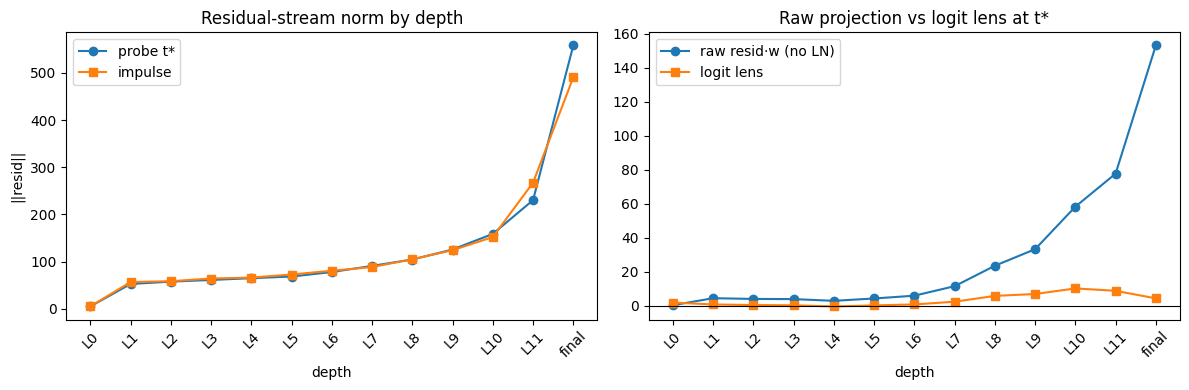

In [8]:
# resid_pre norms at each layer + final resid_post
norms = np.zeros((N_DEPTH, seq_len))
for layer in range(N_LAYERS):
    norms[layer] = cache["resid_pre", layer][0].norm(dim=-1).cpu().numpy()
norms[-1] = cache["resid_post", N_LAYERS - 1][0].norm(dim=-1).cpu().numpy()

# Raw resid · w without ln_final (illustrative only)
raw_proj = np.zeros((N_DEPTH, seq_len))
for layer in range(N_LAYERS):
    raw_proj[layer] = (cache["resid_pre", layer][0] @ w_dir).cpu().numpy()
raw_proj[-1] = (cache["resid_post", N_LAYERS - 1][0] @ w_dir).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(xs, norms[:, T_STAR], marker="o", label="probe t*")
axes[0].plot(xs, norms[:, IMPULSE_POS], marker="s", label="impulse")
axes[0].set_xticks(xs); axes[0].set_xticklabels(DEPTH_LABELS, rotation=45)
axes[0].set_title("Residual-stream norm by depth")
axes[0].set_xlabel("depth"); axes[0].set_ylabel("||resid||"); axes[0].legend()

axes[1].plot(xs, raw_proj[:, T_STAR], marker="o", label="raw resid·w (no LN)")
axes[1].plot(xs, score_logit[:, T_STAR], marker="s", label="logit lens")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_xticks(xs); axes[1].set_xticklabels(DEPTH_LABELS, rotation=45)
axes[1].set_title("Raw projection vs logit lens at t*")
axes[1].set_xlabel("depth"); axes[1].legend()

r = float(np.corrcoef(norms[:, T_STAR], raw_proj[:, T_STAR])[0, 1])
print(f"corr(norm, raw projection) at t*: {r:+.3f}")
print("A large positive value means the un-normalised readout is largely tracking size, not direction.")
plt.tight_layout(); plt.show()

## 5. Secondary — large-fit ridge residual translator (WikiText-2)

Diagnostic only. Fits affine maps `resid_pre[ℓ] → resid_post[final]` on a large corpus so the
original E0 failure mode (N ≪ d_model) is gone, then reads W-vs-C after `ln_final`.

Compare this DIY meter to both logit lens and the pretrained tuned lens. If WikiText fixes R²
but ridge still disagrees with the tuned lens, that supports using the KL-trained lens as the
authoritative instrument.

In [9]:
TARGET_N = 25_000   # token positions; comfortably above 10 × d_model
MAX_SEQ  = 128      # truncate long wiki lines / paragraphs for memory

ds = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")
texts = [t.strip() for t in ds["text"] if t and t.strip() and not t.strip().startswith("=")]
print(f"WikiText-2 non-empty lines available: {len(texts)}")

per_layer_X = [[] for _ in range(N_LAYERS)]
Y_final = []
n_collected = 0

for text in texts:
    if n_collected >= TARGET_N:
        break
    toks = model.to_tokens(text)
    if toks.shape[-1] < 4:
        continue
    toks = toks[:, :MAX_SEQ]
    _, c = model.run_with_cache(toks)
    y = c["resid_post", N_LAYERS - 1][0].float()   # [seq, d]
    for layer in range(N_LAYERS):
        per_layer_X[layer].append(c["resid_pre", layer][0].float())
    Y_final.append(y)
    n_collected += y.shape[0]

per_layer_X = [torch.cat(v, dim=0) for v in per_layer_X]
Y_final = torch.cat(Y_final, dim=0)
N = Y_final.shape[0]
print(f"fitting on N = {N} token positions,  d_model = {D_MODEL}")
if N < 10 * D_MODEL:
    print("  WARNING: N still small relative to d_model; raise TARGET_N.")
else:
    print(f"  OK: N / d_model = {N / D_MODEL:.1f}")

WikiText-2 non-empty lines available: 17556
fitting on N = 25073 token positions,  d_model = 768
  OK: N / d_model = 32.6


In [10]:
def fit_affine(X, Y, ridge=1.0):
    ones = torch.ones(X.shape[0], 1, device=X.device, dtype=X.dtype)
    Xa = torch.cat([X, ones], dim=1)
    G = Xa.T @ Xa
    G = G + ridge * torch.eye(G.shape[0], device=G.device, dtype=G.dtype)
    Sol = torch.linalg.solve(G, Xa.T @ Y)
    return Sol[:-1, :], Sol[-1, :]


def r2_score(Y, pred):
    ss_res = ((Y - pred) ** 2).sum()
    ss_tot = ((Y - Y.mean(0)) ** 2).sum()
    return float(1 - ss_res / ss_tot)


# 80/20 held-out split (same indices for every layer)
rng = np.random.default_rng(0)
perm = rng.permutation(N)
n_train = int(0.8 * N)
train_idx = torch.tensor(perm[:n_train], device=Y_final.device)
test_idx  = torch.tensor(perm[n_train:], device=Y_final.device)

translators = []
r2_train = np.zeros(N_LAYERS)
r2_test  = np.zeros(N_LAYERS)

print(f"{'layer':>6}  {'train R2':>10}  {'heldout R2':>10}")
for layer in range(N_LAYERS):
    X = per_layer_X[layer]
    A, b = fit_affine(X[train_idx], Y_final[train_idx], ridge=1.0)
    translators.append((A, b))
    r2_train[layer] = r2_score(Y_final[train_idx], X[train_idx] @ A + b)
    r2_test[layer]  = r2_score(Y_final[test_idx],  X[test_idx]  @ A + b)
    print(f"{'L'+str(layer):>6}  {r2_train[layer]:10.3f}  {r2_test[layer]:10.3f}")

print("\nHeld-out R2 is what matters. Near-perfect train R2 with poor held-out R2 = overfit / ridge artifact.")

 layer    train R2  heldout R2
    L0       0.372       0.310
    L1       0.446       0.392
    L2       0.473       0.423
    L3       0.500       0.451
    L4       0.525       0.480
    L5       0.548       0.507
    L6       0.587       0.550
    L7       0.632       0.600
    L8       0.687       0.662
    L9       0.748       0.727
   L10       0.839       0.825
   L11       0.927       0.919

Held-out R2 is what matters. Near-perfect train R2 with poor held-out R2 = overfit / ridge artifact.


 depth   ridge↔logit   ridge↔tuned  heldout R2
    L0        -0.107        -0.191       0.310
    L1        +0.579        +0.634       0.392
    L2        +0.478        +0.490       0.423
    L3        +0.410        +0.531       0.451
    L4        +0.534        +0.497       0.480
    L5        +0.580        +0.553       0.507
    L6        +0.497        +0.461       0.550
    L7        +0.720        +0.656       0.600
    L8        +0.911        +0.877       0.662
    L9        +0.957        +0.929       0.727
   L10        +0.967        +0.953       0.825
   L11        +0.983        +0.981       0.919
 final        +1.000        +1.000         n/a


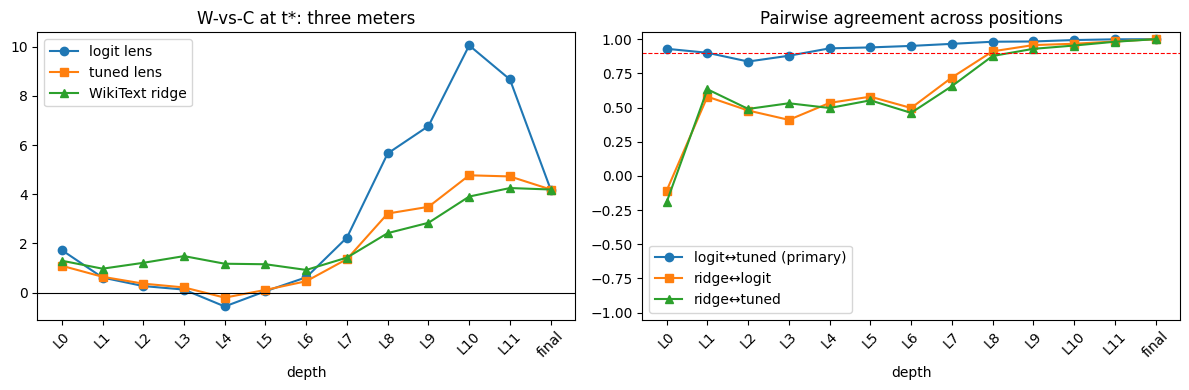

In [11]:
# Apply ridge translators on the experiment prompt; score via full unembed (includes b_U).
score_ridge = np.zeros((N_DEPTH, seq_len))
for layer in range(N_LAYERS):
    A, b = translators[layer]
    hidden = cache["resid_pre", layer][0].float()
    translated = hidden @ A + b
    ridge_logits = model.unembed(model.ln_final(translated))  # [seq, d_vocab]
    score_ridge[layer] = (ridge_logits[:, W_tok] - ridge_logits[:, C_tok]).detach().cpu().numpy()
score_ridge[-1] = wc_diff_from_logits(logits_final)

corrs_ridge_vs_logit = np.array([
    np.corrcoef(score_logit[d], score_ridge[d])[0, 1] for d in range(N_LAYERS)
] + [1.0])
corrs_ridge_vs_tuned = np.array([
    np.corrcoef(score_tuned[d], score_ridge[d])[0, 1] for d in range(N_LAYERS)
] + [1.0])

print(f"{'depth':>6}  {'ridge↔logit':>12}  {'ridge↔tuned':>12}  {'heldout R2':>10}")
for d, lab in enumerate(DEPTH_LABELS):
    r2 = r2_test[d] if d < N_LAYERS else float("nan")
    r2s = f"{r2:10.3f}" if d < N_LAYERS else f"{'n/a':>10}"
    print(f"{lab:>6}  {corrs_ridge_vs_logit[d]:+12.3f}  {corrs_ridge_vs_tuned[d]:+12.3f}  {r2s}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(xs, score_logit[:, T_STAR], marker="o", label="logit lens")
axes[0].plot(xs, score_tuned[:, T_STAR], marker="s", label="tuned lens")
axes[0].plot(xs, score_ridge[:, T_STAR], marker="^", label="WikiText ridge")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_xticks(xs); axes[0].set_xticklabels(DEPTH_LABELS, rotation=45)
axes[0].set_title("W-vs-C at t*: three meters")
axes[0].set_xlabel("depth"); axes[0].legend()

axes[1].plot(xs, corrs, marker="o", label="logit↔tuned (primary)")
axes[1].plot(xs, corrs_ridge_vs_logit, marker="s", label="ridge↔logit")
axes[1].plot(xs, corrs_ridge_vs_tuned, marker="^", label="ridge↔tuned")
axes[1].axhline(0.9, color="red", ls="--", lw=0.8)
axes[1].set_xticks(xs); axes[1].set_xticklabels(DEPTH_LABELS, rotation=45)
axes[1].set_ylim(-1.05, 1.05)
axes[1].set_title("Pairwise agreement across positions")
axes[1].set_xlabel("depth"); axes[1].legend()
plt.tight_layout(); plt.show()

## 6. Control — norm-matched random directions

Is logit↔tuned disagreement specific to the W-vs-C axis, or generic to any direction?

Sample random residual directions with the same norm as `w`. After each lens's
`transform_hidden`, apply `ln_final` and project onto the random direction. Compare the
resulting agreement curve to the W-vs-C logit↔tuned agreement curve.

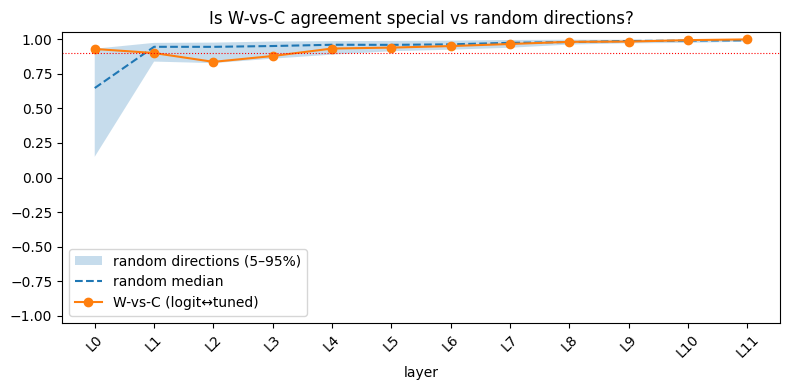

Layers where W-vs-C agreement sits INSIDE the random band (unremarkable):
  L0, L1, L2, L3, L4, L5, L6, L7, L8, L9, L10


In [12]:
N_RANDOM = 30
gen = torch.Generator(device=DEVICE).manual_seed(0)

random_corrs = np.zeros((N_RANDOM, N_LAYERS))

for i in range(N_RANDOM):
    r_dir = torch.randn(D_MODEL, generator=gen, device=DEVICE, dtype=w_dir.dtype)
    r_dir = r_dir / r_dir.norm() * w_dir.norm()

    p_ln = np.zeros((N_LAYERS, seq_len))
    p_tu = np.zeros((N_LAYERS, seq_len))
    for layer in range(N_LAYERS):
        hidden = cache["resid_pre", layer]
        h_logit = logit_lens.transform_hidden(hidden, layer)
        h_tuned = tuned_lens.transform_hidden(hidden, layer)
        p_ln[layer] = (model.ln_final(h_logit)[0] @ r_dir).detach().cpu().numpy()
        p_tu[layer] = (model.ln_final(h_tuned)[0] @ r_dir).detach().cpu().numpy()

    random_corrs[i] = [
        np.corrcoef(p_ln[layer], p_tu[layer])[0, 1] for layer in range(N_LAYERS)
    ]

lo, med, hi = np.percentile(random_corrs, [5, 50, 95], axis=0)
xs_layers = np.arange(N_LAYERS)

plt.figure(figsize=(8, 4))
plt.fill_between(xs_layers, lo, hi, alpha=0.25, label="random directions (5–95%)")
plt.plot(xs_layers, med, ls="--", label="random median")
plt.plot(xs_layers, corrs[:N_LAYERS], marker="o", label="W-vs-C (logit↔tuned)")
plt.axhline(0.9, color="red", ls=":", lw=0.8)
plt.xticks(xs_layers, [f"L{l}" for l in range(N_LAYERS)], rotation=45)
plt.ylim(-1.05, 1.05)
plt.title("Is W-vs-C agreement special vs random directions?")
plt.xlabel("layer"); plt.legend(); plt.tight_layout(); plt.show()

inside = (corrs[:N_LAYERS] >= lo) & (corrs[:N_LAYERS] <= hi)
print("Layers where W-vs-C agreement sits INSIDE the random band (unremarkable):")
print("  " + ", ".join(f"L{l}" for l in range(N_LAYERS) if inside[l]))

## 7. Verdict — trustworthy depth range (primary = tuned lens)

Pre-registered thresholds (same spirit as original E0). Primary gate is agreement with the
**pretrained tuned lens**. Held-out ridge R² is reported as a diagnostic, not a pass condition
for trusting the logit lens.

In [14]:
# --- Pre-register these BEFORE reading outputs above when you re-run seriously ---
CORR_THRESHOLD = 0.90
SIGN_THRESHOLD = 0.90

trustworthy = (corrs[:N_LAYERS] >= CORR_THRESHOLD) & (sign_agree[:N_LAYERS] >= SIGN_THRESHOLD)

print("Per-layer verdict (primary: logit lens vs pretrained tuned lens):")
for layer in range(N_LAYERS):
    mark = "OK     " if trustworthy[layer] else "SUSPECT"
    print(
        f"  L{layer:<2d}  {mark}   corr={corrs[layer]:+.3f}  sign={sign_agree[layer]:.2f}"
        f"  ridge_heldout_R2={r2_test[layer]:.3f}"
    )

ok_layers = [layer for layer in range(N_LAYERS) if trustworthy[layer]]
print()
if ok_layers:
    print(f"TRUSTWORTHY RANGE (logit lens ≈ tuned lens): L{min(ok_layers)} through L{max(ok_layers)}")
    print("E2 / E3 results should be read inside this range, or use the tuned-lens readout outside it.")
else:
    print("NO layer clears both primary thresholds against the pretrained tuned lens.")
    print("Prefer the tuned-lens W-vs-C scores for downstream work on this prompt,")
    print("and re-check on several prompt variants before freezing a depth policy.")

print("\nRidge translator is diagnostic only — do not treat it as a substitute for the tuned lens.")

Per-layer verdict (primary: logit lens vs pretrained tuned lens):
  L0   OK        corr=+0.930  sign=1.00  ridge_heldout_R2=0.310
  L1   OK        corr=+0.900  sign=1.00  ridge_heldout_R2=0.392
  L2   SUSPECT   corr=+0.837  sign=1.00  ridge_heldout_R2=0.423
  L3   SUSPECT   corr=+0.879  sign=0.94  ridge_heldout_R2=0.451
  L4   SUSPECT   corr=+0.933  sign=0.83  ridge_heldout_R2=0.480
  L5   SUSPECT   corr=+0.940  sign=0.89  ridge_heldout_R2=0.507
  L6   OK        corr=+0.951  sign=0.94  ridge_heldout_R2=0.550
  L7   OK        corr=+0.966  sign=0.94  ridge_heldout_R2=0.600
  L8   OK        corr=+0.981  sign=0.94  ridge_heldout_R2=0.662
  L9   SUSPECT   corr=+0.983  sign=0.89  ridge_heldout_R2=0.727
  L10  SUSPECT   corr=+0.994  sign=0.89  ridge_heldout_R2=0.825
  L11  SUSPECT   corr=+0.999  sign=0.89  ridge_heldout_R2=0.919

TRUSTWORTHY RANGE (logit lens ≈ tuned lens): L0 through L8
E2 / E3 results should be read inside this range, or use the tuned-lens readout outside it.

Ridge transla

## 8. What this does and does not establish

**Establishes (for this prompt, GPT-2 small, this W-vs-C contrast):**

- Where the cheap logit lens agrees with a **real** pretrained tuned lens.
- Whether a **large-N WikiText** ridge residual translator was enough to match that lens
  (usually: better fit diagnostics, not a full replacement).
- A recommended depth band for reading logit-lens heatmaps in later experiments.

**Does not establish:**

- Anything about impulse / residue / momentum.
- Generality across prompts — see §9 for a 5-variant re-run of §3 before locking the
  trustworthy range for E2.
- J-lens / causal faithfulness of either meter (patching comes later as E4).

## 9. Prompt variants — is the trustworthy band stable?

Same primary comparison (§3) on 3–5 forced-error prompts that change **operands** and/or **cue phrasing**.
For each variant we record per-layer logit↔tuned correlation / sign agreement, emergence depth, and OK/SUSPECT
under the same thresholds as §7.

Cross-prompt consensus: a layer is **stable-OK** only if it clears both thresholds on **every** variant.

In [15]:
# Forced-error variants: same template, different operands / cue text.
# W_STR / C_STR must be single GPT-2 tokens (leading space before the number).
PROMPT_VARIANTS = [
    {
        "name": "baseline",
        "prompt": "12 + 15 = 25. Wait, let me recompute. 12 + 15 =",
        "W_STR": " 25",
        "C_STR": " 27",
    },
    {
        "name": "ops_8+7",
        "prompt": "8 + 7 = 14. Wait, let me recompute. 8 + 7 =",
        "W_STR": " 14",
        "C_STR": " 15",
    },
    {
        "name": "cue_actually",
        "prompt": "9 + 6 = 16. Actually that's wrong. 9 + 6 =",
        "W_STR": " 16",
        "C_STR": " 15",
    },
    {
        "name": "cue_hold_on",
        "prompt": "20 + 5 = 24. Hold on, let me check. 20 + 5 =",
        "W_STR": " 24",
        "C_STR": " 25",
    },
    {
        "name": "ops_11+12",
        "prompt": "11 + 12 = 22. No wait. 11 + 12 =",
        "W_STR": " 22",
        "C_STR": " 23",
    },
]


def calibrate_prompt(prompt, W_STR, C_STR):
    """Primary logit↔tuned calibration for one forced-error prompt."""
    W_tok = model.to_single_token(W_STR)
    C_tok = model.to_single_token(C_STR)

    tokens = model.to_tokens(prompt)
    str_tokens = model.to_str_tokens(prompt)
    impulse_positions = find_token_indices(str_tokens, W_STR)
    eq_positions = find_token_indices(str_tokens, " =")
    if not impulse_positions:
        raise ValueError(f"impulse token {W_STR!r} not found in {str_tokens}")
    if not eq_positions:
        raise ValueError(f"no ' =' positions in {str_tokens}")
    impulse_pos = impulse_positions[0]
    t_star = eq_positions[-1]

    logits_final, cache = model.run_with_cache(tokens, return_type="logits")
    seq_len = tokens.shape[-1]

    def wc_diff(layer_logits):
        return (layer_logits[0, :, W_tok] - layer_logits[0, :, C_tok]).detach().float().cpu().numpy()

    score_logit = np.zeros((N_DEPTH, seq_len))
    score_tuned = np.zeros((N_DEPTH, seq_len))
    for layer in range(N_LAYERS):
        hidden = cache["resid_pre", layer]
        score_logit[layer] = wc_diff(logit_lens.forward(hidden, layer))
        score_tuned[layer] = wc_diff(tuned_lens.forward(hidden, layer))
    score_logit[-1] = wc_diff(logits_final)
    score_tuned[-1] = wc_diff(logits_final)

    corrs = np.array([
        np.corrcoef(score_logit[d], score_tuned[d])[0, 1] for d in range(N_LAYERS)
    ])
    sign_agree = np.array([
        np.mean(np.sign(score_logit[d]) == np.sign(score_tuned[d])) for d in range(N_LAYERS)
    ])
    trustworthy = (corrs >= CORR_THRESHOLD) & (sign_agree >= SIGN_THRESHOLD)

    e_logit = emergence_layer(score_logit[:, t_star])
    e_tuned = emergence_layer(score_tuned[:, t_star])

    return {
        "prompt": prompt,
        "W_STR": W_STR,
        "C_STR": C_STR,
        "str_tokens": str_tokens,
        "impulse_pos": impulse_pos,
        "t_star": t_star,
        "score_logit": score_logit,
        "score_tuned": score_tuned,
        "corrs": corrs,
        "sign_agree": sign_agree,
        "trustworthy": trustworthy,
        "e_logit": e_logit,
        "e_tuned": e_tuned,
        "final_wc": float(score_logit[-1, t_star]),
    }


# Sanity-check that W/C strings are single tokens before the full sweep.
print("Token sanity check:")
for v in PROMPT_VARIANTS:
    w_id = model.to_single_token(v["W_STR"])
    c_id = model.to_single_token(v["C_STR"])
    print(f"  {v['name']:<14}  W={v['W_STR']!r}->{w_id}  C={v['C_STR']!r}->{c_id}")

Token sanity check:
  baseline        W=' 25'->1679  C=' 27'->2681
  ops_8+7         W=' 14'->1478  C=' 15'->1315
  cue_actually    W=' 16'->1467  C=' 15'->1315
  cue_hold_on     W=' 24'->1987  C=' 25'->1679
  ops_11+12       W=' 22'->2534  C=' 23'->2242


In [16]:
variant_results = []
for v in PROMPT_VARIANTS:
    print("=" * 72)
    print(f"{v['name']}: {v['prompt']!r}")
    r = calibrate_prompt(v["prompt"], v["W_STR"], v["C_STR"])
    r["name"] = v["name"]
    variant_results.append(r)

    print(f"  impulse@{r['impulse_pos']}={r['str_tokens'][r['impulse_pos']]!r}  "
          f"t*@{r['t_star']}={r['str_tokens'][r['t_star']]!r}  "
          f"final W-C={r['final_wc']:+.3f}")
    print(f"  emergence: logit={fmt_depth(r['e_logit'])}  tuned={fmt_depth(r['e_tuned'])}",
          end="")
    if r["e_logit"] == r["e_tuned"]:
        print("  (agree)")
    else:
        print("  (DISAGREE)")

    ok = [layer for layer in range(N_LAYERS) if r["trustworthy"][layer]]
    print("  per-layer:", end="")
    for layer in range(N_LAYERS):
        mark = "OK" if r["trustworthy"][layer] else ".."
        print(f" L{layer}:{mark}", end="")
    print()
    if ok:
        print(f"  OK layers: {ok}")
    else:
        print("  OK layers: (none)")

# Consensus: OK on every variant
corr_mat = np.stack([r["corrs"] for r in variant_results], axis=0)          # [n_var, n_layers]
sign_mat = np.stack([r["sign_agree"] for r in variant_results], axis=0)
ok_mat = np.stack([r["trustworthy"] for r in variant_results], axis=0)
stable_ok = ok_mat.all(axis=0)
stable_layers = [layer for layer in range(N_LAYERS) if stable_ok[layer]]

print("\n" + "=" * 72)
print(f"Cross-prompt stable-OK (corr≥{CORR_THRESHOLD}, sign≥{SIGN_THRESHOLD} on ALL variants):")
if stable_layers:
    print(f"  L{min(stable_layers)} through contiguous? "
          f"{'yes' if stable_layers == list(range(min(stable_layers), max(stable_layers)+1)) else 'no — see list'}")
    print(f"  layers: {stable_layers}")
else:
    print("  (none — prefer tuned-lens readout; do not freeze a logit-lens depth policy yet)")

n_ok = ok_mat.sum(axis=0)
print("\n#variants OK per layer:")
for layer in range(N_LAYERS):
    print(f"  L{layer:<2d}  {int(n_ok[layer])}/{len(variant_results)}  "
          f"min_corr={corr_mat[:, layer].min():+.3f}  min_sign={sign_mat[:, layer].min():.2f}")

baseline: '12 + 15 = 25. Wait, let me recompute. 12 + 15 ='
  impulse@5=' 25'  t*@17=' ='  final W-C=+4.194
  emergence: logit=L5  tuned=L5  (agree)
  per-layer: L0:OK L1:OK L2:.. L3:.. L4:.. L5:.. L6:OK L7:OK L8:OK L9:.. L10:.. L11:..
  OK layers: [0, 1, 6, 7, 8]
ops_8+7: '8 + 7 = 14. Wait, let me recompute. 8 + 7 ='
  impulse@5=' 14'  t*@17=' ='  final W-C=+2.444
  emergence: logit=L6  tuned=L6  (agree)
  per-layer: L0:.. L1:.. L2:OK L3:OK L4:OK L5:OK L6:.. L7:.. L8:.. L9:OK L10:OK L11:OK
  OK layers: [2, 3, 4, 5, 9, 10, 11]
cue_actually: "9 + 6 = 16. Actually that's wrong. 9 + 6 ="
  impulse@5=' 16'  t*@15=' ='  final W-C=+3.074
  emergence: logit=L6  tuned=L6  (agree)
  per-layer: L0:.. L1:.. L2:OK L3:.. L4:OK L5:OK L6:.. L7:OK L8:.. L9:OK L10:.. L11:..
  OK layers: [2, 4, 5, 7, 9]
cue_hold_on: '20 + 5 = 24. Hold on, let me check. 20 + 5 ='
  impulse@5=' 24'  t*@17=' ='  final W-C=+2.961
  emergence: logit=L1  tuned=L1  (agree)
  per-layer: L0:.. L1:.. L2:.. L3:.. L4:.. L5:OK L6:OK

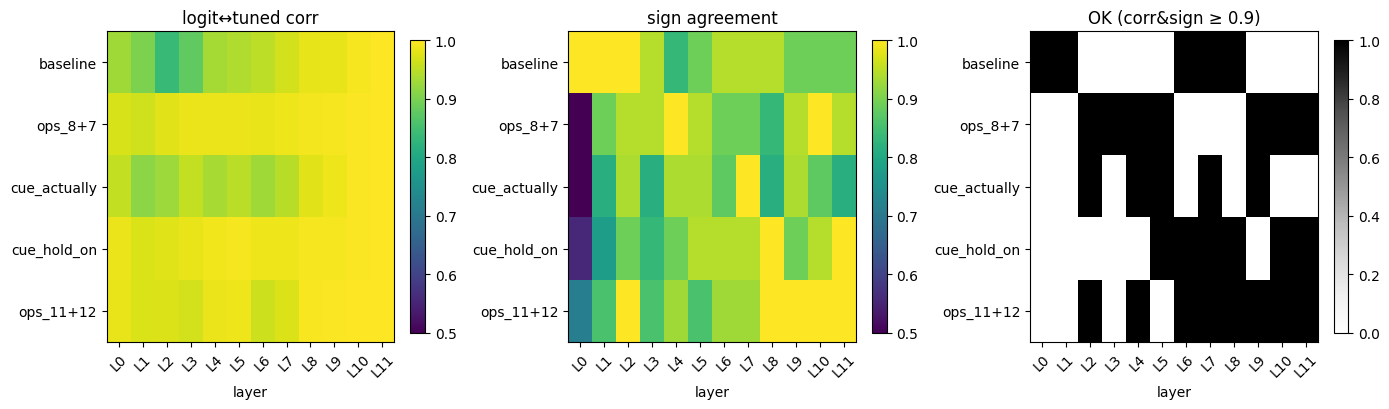

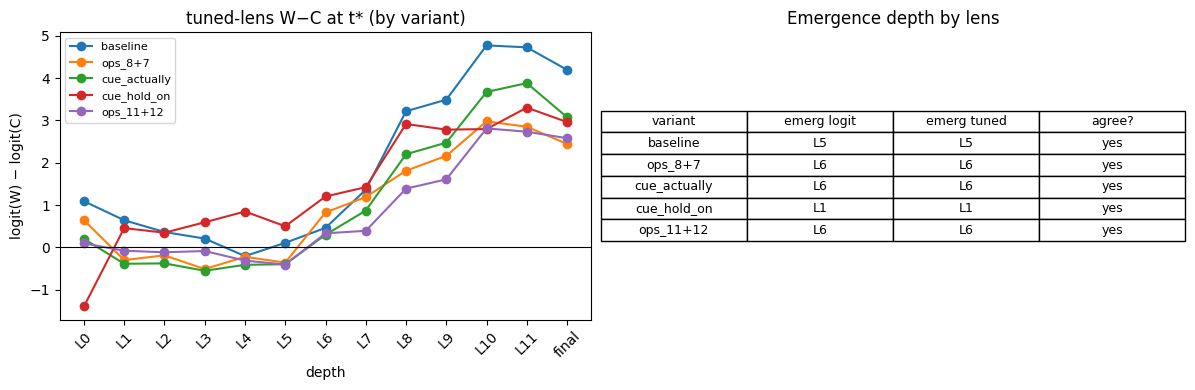

Practical takeaway for E2:
  No layer is stable-OK across all variants — treat tuned lens as the default meter.
  Prefer reporting tuned-lens curves as primary; use logit lens only where this sweep agrees.


In [17]:
# Heatmaps: corr / sign / OK across variants × layers
names = [r["name"] for r in variant_results]
xs_layers = np.arange(N_LAYERS)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

im0 = axes[0].imshow(corr_mat, aspect="auto", vmin=0.5, vmax=1.0, cmap="viridis")
axes[0].set_title("logit↔tuned corr")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(sign_mat, aspect="auto", vmin=0.5, vmax=1.0, cmap="viridis")
axes[1].set_title("sign agreement")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(ok_mat.astype(float), aspect="auto", vmin=0, vmax=1, cmap="Greys")
axes[2].set_title(f"OK (corr&sign ≥ {CORR_THRESHOLD})")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.set_xticks(xs_layers)
    ax.set_xticklabels([f"L{l}" for l in xs_layers], rotation=45)
    ax.set_yticks(np.arange(len(names)))
    ax.set_yticklabels(names)
    ax.set_xlabel("layer")

plt.tight_layout()
plt.show()

# Emergence + final W-C across variants
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for r in variant_results:
    axes[0].plot(xs, r["score_tuned"][:, r["t_star"]], marker="o", label=r["name"])
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_xticks(xs)
axes[0].set_xticklabels(DEPTH_LABELS, rotation=45)
axes[0].set_title("tuned-lens W−C at t* (by variant)")
axes[0].set_xlabel("depth")
axes[0].set_ylabel("logit(W) − logit(C)")
axes[0].legend(fontsize=8)

emerg_rows = []
for r in variant_results:
    emerg_rows.append((r["name"], fmt_depth(r["e_logit"]), fmt_depth(r["e_tuned"]),
                       "yes" if r["e_logit"] == r["e_tuned"] else "NO"))
axes[1].axis("off")
table = axes[1].table(
    cellText=emerg_rows,
    colLabels=["variant", "emerg logit", "emerg tuned", "agree?"],
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.1, 1.4)
axes[1].set_title("Emergence depth by lens")

plt.tight_layout()
plt.show()

print("Practical takeaway for E2:")
if stable_layers:
    print(f"  Logit lens is stable-OK only at layers {stable_layers}.")
    print("  Outside that set, read W−C with the pretrained tuned lens.")
else:
    print("  No layer is stable-OK across all variants — treat tuned lens as the default meter.")
print("  Prefer reporting tuned-lens curves as primary; use logit lens only where this sweep agrees.")